In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

In [6]:
df = pd.read_csv("../outputs/customer_level_dataset_v1.csv")
print(df.shape)
df.head()

(16737, 38)


,customer_id,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,enrollment_date,cancellation_date,active_months,first_activity,last_activity,total_flights,total_distance,total_points_accumulated,total_points_redeemed,total_redeemed_dollars,avg_flights_per_month,avg_monthly_distance,recency_months,activity_span_months,points_redemption_ratio,distance_per_flight,flights_per_active_month,official_churn,behavioral_churn,churn,salary_imputed,tenure_months
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN,2016-02-01,NaN,24,2017-01-01,2018-12-01,37,54525,54525.0,1418,256,1.541667,2271.875000,0,24,0.026006,1473.648649,1.541667,0,0,0,83236.0,34
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN,2016-03-01,NaN,24,2017-01-01,2018-12-01,58,77487,77487.0,1971,356,2.416667,3228.625000,0,24,0.025437,1335.982759,2.416667,0,0,0,73455.0,33
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0,2014-07-01,2018-01-01,24,2017-01-01,2018-12-01,18,24803,24803.0,374,67,0.750000,1033.458333,0,24,0.015079,1377.944444,0.750000,1,0,1,73455.0,53
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN,2013-02-01,NaN,24,2017-01-01,2018-12-01,35,48432,48432.0,1291,233,1.458333,2018.000000,0,24,0.026656,1383.771429,1.458333,0,0,0,73455.0,70
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN,2014-10-01,NaN,24,2017-01-01,2018-12-01,37,55515,55515.0,0,0,1.541667,2313.125000,0,24,0.000000,1500.405405,1.541667,0,0,0,103495.0,50


In [7]:
segmentation_features = [
    "clv",
    "total_flights",
    "total_distance",
    "active_months",
    "avg_flights_per_month",
    "points_redemption_ratio",
    "salary_imputed",
    "tenure_months"
]

segment_df = df[segmentation_features].copy()
segment_df.head()

,clv,total_flights,total_distance,active_months,avg_flights_per_month,points_redemption_ratio,salary_imputed,tenure_months
0,3839.14,37,54525,24,1.541667,0.026006,83236.0,34
1,3839.61,58,77487,24,2.416667,0.025437,73455.0,33
2,3839.75,18,24803,24,0.750000,0.015079,73455.0,53
3,3839.75,35,48432,24,1.458333,0.026656,73455.0,70
4,3842.79,37,55515,24,1.541667,0.000000,103495.0,50


In [8]:
df = df.replace([np.inf, -np.inf], np.nan)

df["points_redemption_ratio"] = df["points_redemption_ratio"].fillna(0)
df["avg_flights_per_month"] = df["avg_flights_per_month"].fillna(0)
df["distance_per_flight"] = df["distance_per_flight"].fillna(0)

segment_df = df[segmentation_features].copy()
segment_df = segment_df.replace([np.inf, -np.inf], 0)
segment_df = segment_df.fillna(0)

print(segment_df.isnull().sum())
print(np.isinf(segment_df).sum())

clv                        0
total_flights              0
total_distance             0
active_months              0
avg_flights_per_month      0
points_redemption_ratio    0
salary_imputed             0
tenure_months              0
dtype: int64
clv                        0
total_flights              0
total_distance             0
active_months              0
avg_flights_per_month      0
points_redemption_ratio    0
salary_imputed             0
tenure_months              0
dtype: int64


In [9]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(segment_df)
scaled_data[:5]

array([[-0.60485224,  0.39133044,  0.34285571,  0.24816976,  0.1464018 ,
         0.38426265,  0.17975192, -0.18183885],
       [-0.60478374,  1.6365088 ,  1.22291044,  0.24816976,  0.98462056,
         0.36205236, -0.14245255, -0.22420236],
       [-0.60476333, -0.73525951, -0.79628664,  0.24816976, -0.6119866 ,
        -0.04161483, -0.14245255,  0.62306782],
       [-0.60476333,  0.27274202,  0.10933191,  0.24816976,  0.06657144,
         0.40957582, -0.14245255,  1.34324748],
       [-0.60432023,  0.39133044,  0.38079902,  0.24816976,  0.1464018 ,
        -0.62927649,  0.84712133,  0.4959773 ]])

In [10]:
wcss = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(scaled_data)
    wcss.append(model.inertia_)

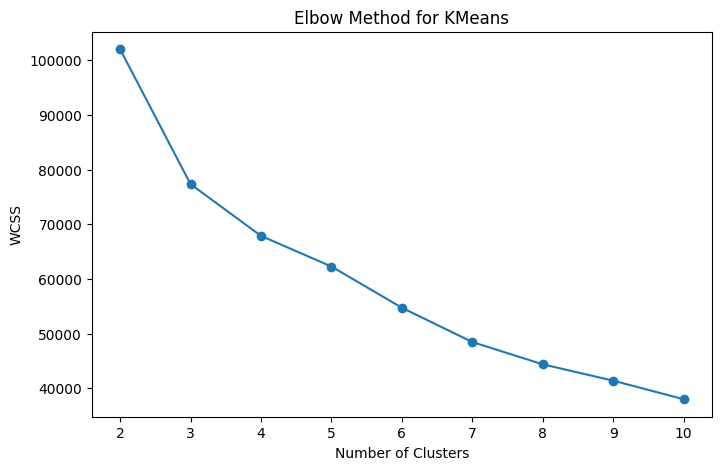

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method for KMeans")
plt.show()

In [12]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(scaled_data)

df["cluster"].value_counts().sort_index()

cluster
0    6313
1    5132
2    3962
3     889
4     441
Name: count, dtype: int64

In [13]:
cluster_profile = df.groupby("cluster")[[
    "clv",
    "total_flights",
    "total_distance",
    "active_months",
    "avg_flights_per_month",
    "points_redemption_ratio",
    "salary_imputed",
    "tenure_months",
    "churn"
]].mean().round(2)

cluster_profile

,clv,total_flights,total_distance,active_months,avg_flights_per_month,points_redemption_ratio,salary_imputed,tenure_months,churn
cluster,,,,,,,,,
0,9008.81,41.25,62368.05,24.00,1.70,0.02,74361.79,58.38,0.01
1,6420.45,32.46,48097.83,24.00,1.35,0.02,74296.00,29.11,0.04
2,8440.80,6.09,9034.69,23.81,0.25,0.01,73863.72,24.49,0.40
3,8006.66,49.41,74174.70,11.00,4.47,0.00,66485.73,8.97,0.12
4,7545.20,31.25,46615.45,23.32,1.38,0.02,225184.20,40.79,0.12


In [14]:
segment_names = {
    0: "Frequent Travelers",
    1: "At-Risk Customers",
    2: "High Value Customers",
    3: "Loyal Customers",
    4: "Premium Affluent Customers"
}

df["customer_segment"] = df["cluster"].map(segment_names)
df[["cluster", "customer_segment"]].head()

,cluster,customer_segment
0,1,At-Risk Customers
1,0,Frequent Travelers
2,2,High Value Customers
3,0,Frequent Travelers
4,0,Frequent Travelers


In [15]:
df["customer_segment"].value_counts()

customer_segment
Frequent Travelers            6313
At-Risk Customers             5132
High Value Customers          3962
Loyal Customers                889
Premium Affluent Customers     441
Name: count, dtype: int64

In [16]:
segment_distribution = pd.DataFrame({
    "Customers": df["customer_segment"].value_counts(),
    "Percentage": round(df["customer_segment"].value_counts(normalize=True) * 100, 2)
})

segment_distribution

,Customers,Percentage
customer_segment,,
Frequent Travelers,6313,37.72
At-Risk Customers,5132,30.66
High Value Customers,3962,23.67
Loyal Customers,889,5.31
Premium Affluent Customers,441,2.63


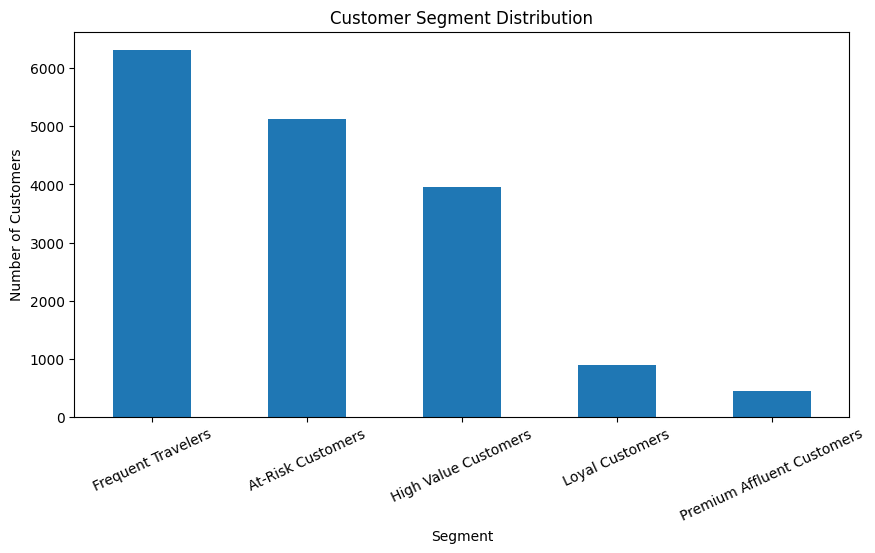

In [17]:
df["customer_segment"].value_counts().plot(kind="bar", figsize=(10, 5))
plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=25)
plt.show()

In [18]:
df.to_csv("../outputs/customer_segments.csv", index=False)
print("Saved customer_segments.csv")

Saved customer_segments.csv


In [19]:
print("Customer segmentation completed successfully.")

Customer segmentation completed successfully.
